# Statistics of NMRlipids databank

This notebook plots:
1. Distributions of simulation lengths, number of atoms and trajectory sizes
2. Distribution of number of lipid components
3. Available single component bilayers and binary lipid mixtures
4. Pie diagram of temperatures

# Initializing databank

In [23]:
from DatabankLib.protein_functions import *
import yaml

databankPath = "/home/sosamuli/work/NMRlipids/IDPdatabank/"  # this is the local path for the cloned Databank
os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPdatabank/"

#databankPath = "/home/sosamuli/work/NMRlipids/IDPsimBank/"  # this is the local path for the cloned Databank
#os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPsimBank/"



# These two lines include core Databank routines and Databank API
from DatabankLib.core import *
from DatabankLib.databankLibrary import *
# This is for plotting
from DatabankLib.databankio import *
from DatabankLib.plottings import plotSimulation
#from IPython.display import display, Markdown

# This initializes the databank and stores the information of all simulations into a list.
# Each list item contains the information from README.yaml file of the given simulation.
systems = initialize_databank()


Databank initialized from the folder: /home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations


In [2]:
for system in systems:
    print(system)

System(285): 293/5ab/2935abc7e8e23ff3ea5f188b85eb7cb00a51b8ea/11414db728147aeb0e0e7bfe179d61c5b0f33b84/
System(138): 7ba/91f/7ba91f0ff97f2a73cae20f5eec60e1c9040aaed6/4679d7713aabbcab3b480e0d63ed1e645aef0495/
System(103): 7ba/bf0/7babf08d76a410719cdfac0b58fabcd010cb2e8f/fb43125cd3952f71f14aa490fb97d0e24292106e/
System(1): f8e/81d/f8e81d87d1c190bc5ec45084165e12dec9ed5d13/c26e9d4317436c590fe19ecff68b36cdcc8508d9/
System(190): c47/d30/c47d306dfd7e9a92017502c9a16807af20d3067b/65a745950bfc465f170f5b3109e8e37b4af9512c/
System(270): 13f/9f7/13f9f795dc67151fe112c4ea0f270e1f417b1374/307220bf27bf2f72b8d364bd7c603dcb18556f75/
System(52): c5c/94a/c5c94a1f5c1aa87393804181dd4630b40eae58f9/babd9acb94742a58359e7ca0c7541ee9c6fdafb8/
System(53): c5c/c48/c5cc48a02c7f00bed3b61fb7b3fe1aed297c7e2b/cfe12464ae23c121917db0af7981379cbe055c55/
System(152): f94/f3b/f94f3b4bb2a04e97e8973c1b824053b91c5890c7/99b1d9ff07c519b33710f1e4d2dec4a59082324b/
System(2): cdf/798/cdf7987102d6473c8ad0ab8a4f7c384b16b4cb5b/bab80edf

KeyError: 'ID'

# Plot distributions of simulation lengths, number of atoms and trajectory sizes

Number of entries:  315
Total size of trajectories:  347.528451167047 Gb
Total time of trajectories:  497558.70999999996 ns


Text(0, 0.5, 'Distribution')

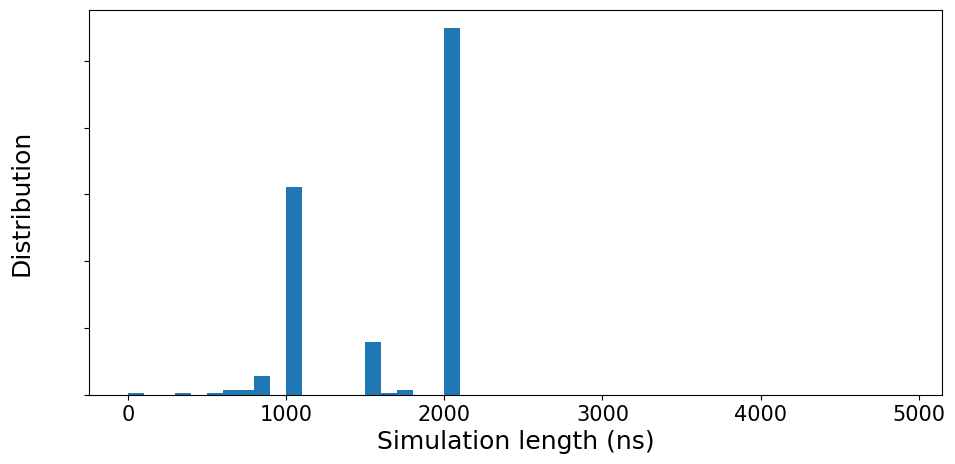

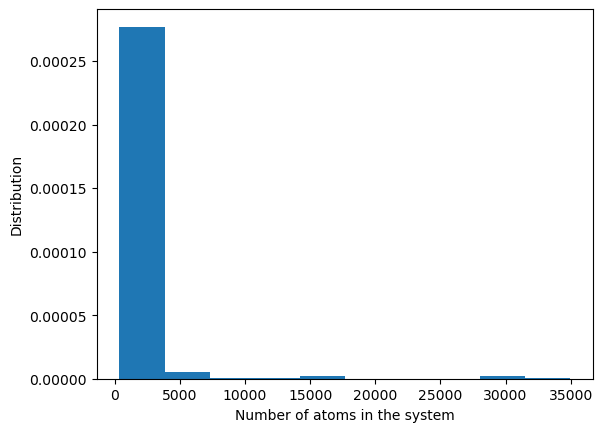

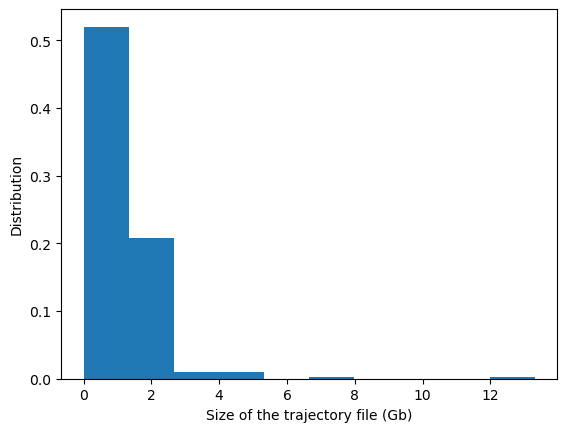

In [24]:
SimulationLengths = []
NumberOfAtoms = []
SizeOfTrajectories = []

# Loop over simulations in the Databank
for system in systems:
    SimulationLengths.append(system['TRJLENGTH']*0.001)
    NumberOfAtoms.append(system['NUMBER_OF_ATOMS'])
    SizeOfTrajectories.append(system['TRAJECTORY_SIZE']/(1024*1024*1024))
    
print("Number of entries: ",len(systems))
print("Total size of trajectories: ",str(np.sum(SizeOfTrajectories)) + ' Gb')
print("Total time of trajectories: ",str(np.sum(SimulationLengths)) + ' ns')

plt.figure(figsize=(11,5))
distSIMl = plt.hist(SimulationLengths, density=True,bins=np.arange(0,5000,100))
plt.xlabel('Simulation length (ns)', fontsize=18)
plt.ylabel('Distribution', fontsize=18)
plt.yticks(color='w')
plt.xticks(fontsize=15)
plt.figure()
distNatoms = plt.hist(NumberOfAtoms, density=True)
plt.xlabel('Number of atoms in the system')
plt.ylabel('Distribution')
plt.figure()
disttrjSIZE = plt.hist(SizeOfTrajectories, density=True)
plt.xlabel('Size of the trajectory file (Gb)')
plt.ylabel('Distribution')

# Plot distribution of different proteins

{'Charged sequence with tris': 3, 'KRS1-72_salt': 25, 'asyn_salt': 25, 'KRS1-72': 25, 'wrapping silk (AcSp1)': 25, 'Protein linker': 7, 'asyn': 25, 'ChiZ_salt': 25, 'ChiZ1-64': 25, 'Charged sequence with NaCl': 6, 'calmodulin': 25, 'silk protein': 25, 'TonBCTD': 25, 'icl2': 25, 'CDNF': 10, 'Charged protonated sequence with CaCl': 1, 'Charged sequence with NaCl and phosphate': 2, 'Charged sequence with CaCl': 1, 'Charged protonated sequence with NaCl': 1, 'Charged sequence with CaCl and phosphate': 1, 'TonB': 1, 'Charged sequence protonated peptide': 1, 'TonB low pH with CaCl': 1, 'Charged sequence peptide': 1, 'EN2': 1, 'TonB low pH with NaCl': 1, 'Calmodulin': 1, 'TonB with CaCl, deprotonated': 1}


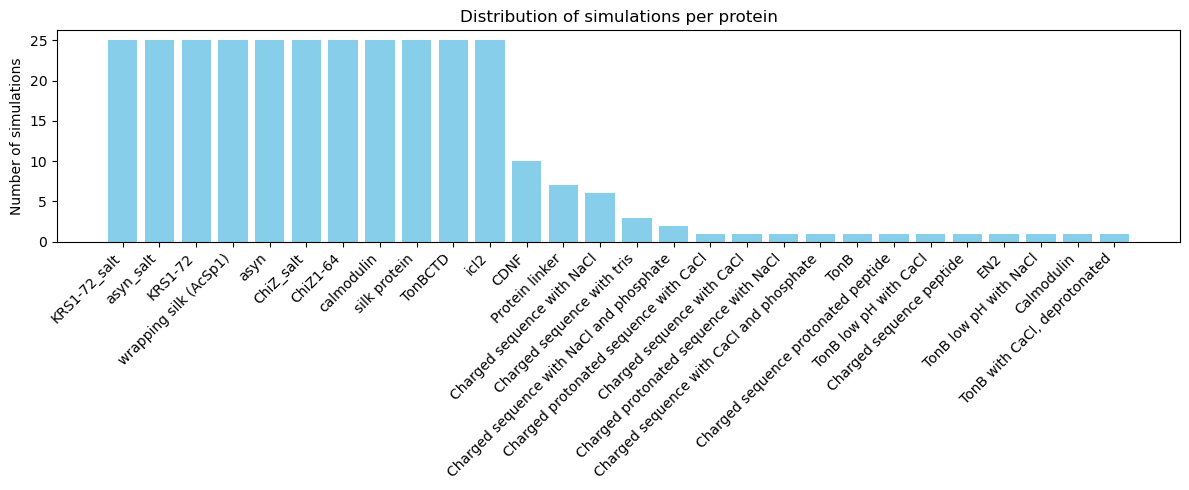

In [25]:
# Loop over simulations in the Databank

system_descriptions = {}

for system in systems:
    #print(system['COMPOSITION']['PROTEIN']['SEQUENCE'])
    system_description = system['SYSTEM']
    if system_description not in system_descriptions:
        system_descriptions[system_description] = 1
    else:
        system_descriptions[system_description] += 1
    
    #print(system['FF'])
print(system_descriptions)
    
# Your dictionary
protein_counts = system_descriptions

# Sort by counts (optional)
sorted_items = dict(sorted(protein_counts.items(), key=lambda x: x[1], reverse=True))

# Create bar plot
plt.figure(figsize=(12,5))
plt.bar(sorted_items.keys(), sorted_items.values(), color='skyblue')

plt.ylabel("Number of simulations")
plt.title("Distribution of simulations per protein")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot distribution of different force fields

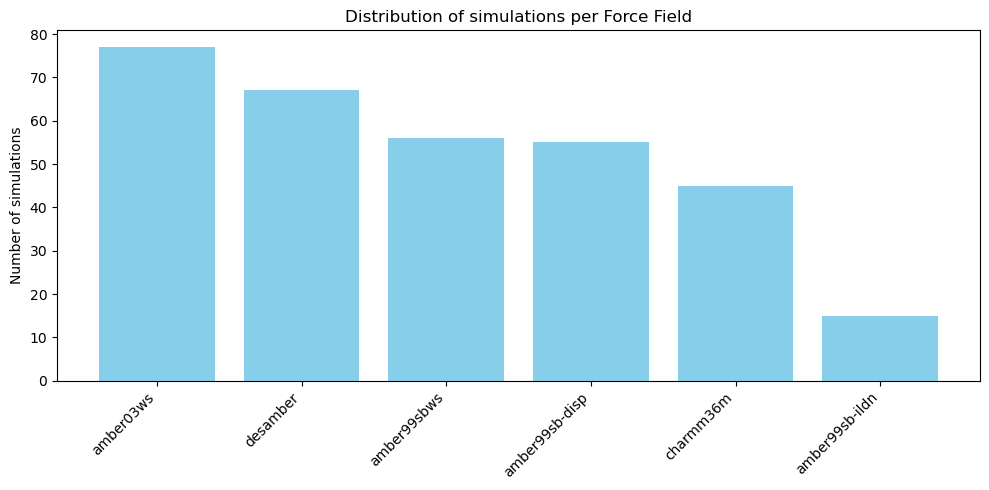

In [26]:
import matplotlib.pyplot as plt

# Mapping of variant names to canonical force field names
ff_canonical = {
    'amberff03ws': 'amber03ws',
    'amber03ws': 'amber03ws',
    'amber99sbws': 'amber99sbws',
    'amber99sb-disp': 'amber99sb-disp',
    'desamber': 'desamber',
    'charmm36m': 'charmm36m',
}

# Count simulations per (canonical) force field
system_descriptions = {}

for system in systems:
    ff = str(system['FF']).strip().lower()  # normalize
    ff = ff_canonical.get(ff, ff)          # map to canonical name
    
    if ff in ['none','nan','unknown']:
        continue  # skip invalid FFs
    
    if ff not in system_descriptions:
        system_descriptions[ff] = 1
    else:
        system_descriptions[ff] += 1

# Your dictionary
protein_counts = system_descriptions

# Sort by counts (optional)
sorted_items = dict(sorted(protein_counts.items(), key=lambda x: x[1], reverse=True))

# Create bar plot
plt.figure(figsize=(10,5))
plt.bar(sorted_items.keys(), sorted_items.values(), color='skyblue')

plt.ylabel("Number of simulations")
plt.title("Distribution of simulations per Force Field")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

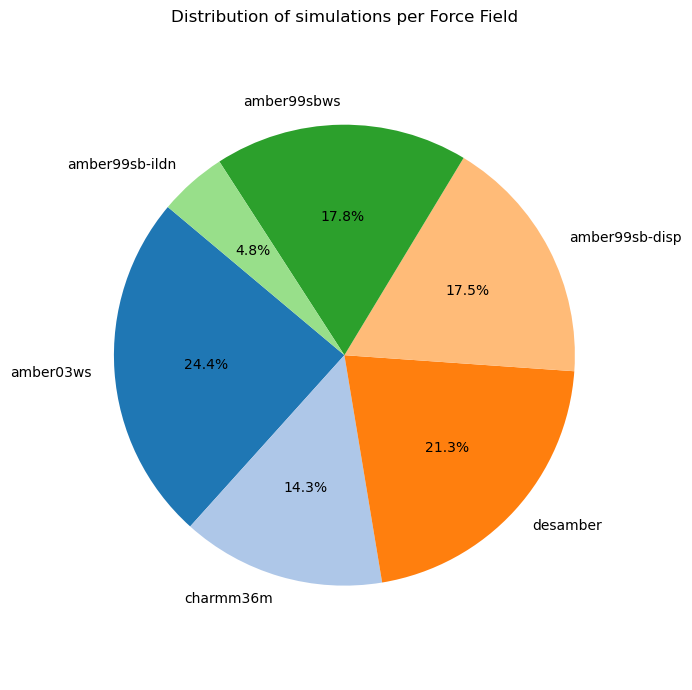

In [27]:
import matplotlib.pyplot as plt

# Use the same system_descriptions dictionary from your previous step
labels = list(system_descriptions.keys())
sizes = list(system_descriptions.values())

# Create pie chart
plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
plt.title("Distribution of simulations per Force Field")
plt.axis('equal')  # Equal aspect ratio ensures the pie is circular
plt.tight_layout()
plt.show()

# Sequence information

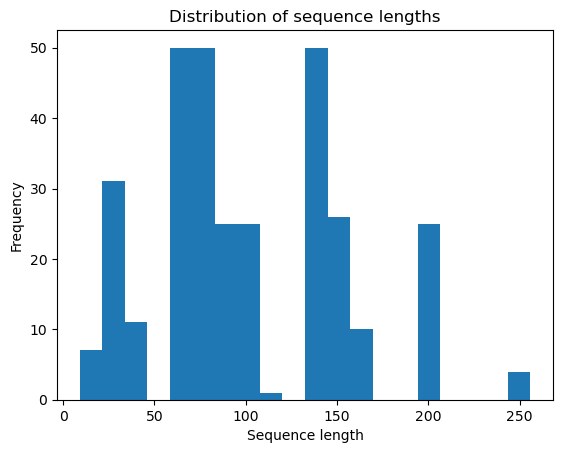

Sequence lengths:
[35, 72, 140, 72, 200, 9, 140, 140, 67, 67, 35, 72, 67, 148, 67, 148, 199, 140, 72, 67, 72, 33, 72, 72, 9, 33, 67, 72, 140, 92, 67, 72, 67, 67, 67, 33, 100, 140, 100, 161, 33, 33, 100, 140, 72, 72, 67, 72, 148, 199, 199, 148, 100, 72, 67, 67, 100, 33, 100, 140, 67, 92, 92, 92, 92, 67, 140, 35, 140, 140, 67, 200, 161, 67, 33, 72, 100, 35, 161, 92, 148, 140, 148, 140, 199, 67, 72, 72, 199, 100, 9, 67, 92, 92, 161, 200, 100, 72, 67, 140, 67, 92, 148, 35, 72, 67, 140, 33, 140, 33, 72, 100, 140, 67, 67, 72, 199, 140, 33, 100, 200, 72, 140, 140, 148, 199, 33, 199, 100, 92, 35, 140, 140, 140, 148, 140, 92, 148, 140, 140, 140, 92, 67, 148, 33, 67, 33, 92, 92, 148, 72, 140, 67, 148, 67, 72, 100, 100, 12, 100, 72, 140, 72, 100, 148, 35, 72, 140, 92, 67, 67, 67, 72, 33, 33, 140, 92, 72, 33, 35, 33, 100, 199, 161, 67, 33, 148, 67, 67, 148, 92, 9, 72, 67, 67, 33, 199, 33, 256, 148, 148, 100, 92, 33, 12, 67, 67, 67, 92, 33, 199, 148, 67, 72, 100, 72, 199, 67, 100, 140, 161, 140, 14

In [28]:
from collections import Counter

sequences = []

for system in systems:
    sequences.append(system['COMPOSITION']['PROTEIN']['SEQUENCE'])

#print(sequences)

# --- 1. Compute sequence lengths ---
lengths = [len(seq) for seq in sequences]

# --- 2. Plot distribution of sequence lengths ---
plt.figure()
plt.hist(lengths, bins=20)
plt.xlabel("Sequence length")
plt.ylabel("Frequency")
plt.title("Distribution of sequence lengths")
plt.show()

# --- 3. Get unique sequences ---
unique_sequences = list(set(sequences))

# --- 4. Count number of unique sequences ---
num_unique_sequences = len(unique_sequences)

# --- 5. (Optional) Count frequency of each sequence ---
sequence_counts = Counter(sequences)

# --- Output results ---
print("Sequence lengths:")
print(lengths)

print("\nUnique sequences:")
print(unique_sequences)

print("\nNumber of unique sequences:")
print(num_unique_sequences)

print("\nSequence counts (frequency):")
print(sequence_counts)

# Disorder information

In [31]:
for system in systems:
    path = databankPath + '/Data/Simulations/' + (system['path'])
    secondary_structure_file = path + '/secondary_structure.yaml'
    with open(secondary_structure_file, "r") as f:
        secondary_structure_data = yaml.safe_load(f)
    print(secondary_structure_data)
    print()

{'10_V': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '11_P': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '12_K': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '13_P': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '14_K': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '15_P': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '16_K': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '17_P': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '18_K': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '19_P': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '1_K': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '20_K': {'

FileNotFoundError: [Errno 2] No such file or directory: '/home/sosamuli/work/NMRlipids/IDPdatabank//Data/Simulations/8e2/c75/8e2c75ee99bf9c665240a422124d0ce0ac6ea357/5e0ddfacaae9d723c7422b27d1ccda41d8b80358//secondary_structure.yaml'

Missing: /home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations/6c1/ec1/6c1ec19d558593835a8d110b80a260d900335ca8/3178d58f027b7b9d6cbc6e7ad119e04c03ad92f2/secondary_structure.yaml
Missing: /home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations/7b6/89c/7b689ca8088676ddb9948f10b2772ac9d3eacf2c/5becb66d4a4c69336f69bda615862401fb17eec3/secondary_structure.yaml
Missing: /home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations/478/6f7/4786f7ff9de4a91784c7a041e50ed99fc640241b/0b818c55d986e8db216730c597450eda95583ba6/secondary_structure.yaml
Missing: /home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations/cd2/400/cd24007d32dee6128ec8137f3e5617d1a3095dad/7ba34e70620896effe41402802edc30874b9d912/secondary_structure.yaml
Missing: /home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations/930/7cd/9307cd81ffdf206cdd921c60fb45522aa475e6ec/ed87dc4213b850295c10f8968473e296e66b60af/secondary_structure.yaml
Missing: /home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations/e1a/27b/e1a27bb90

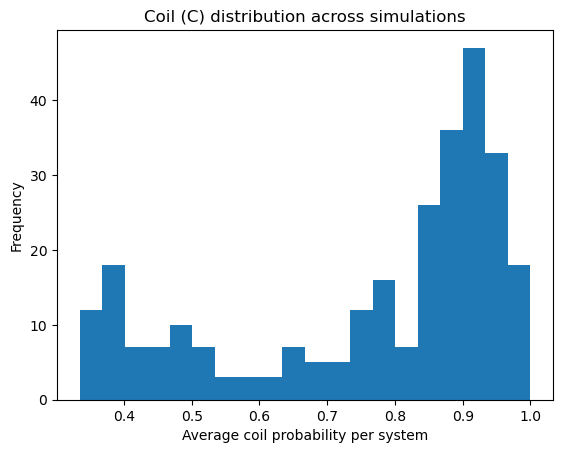

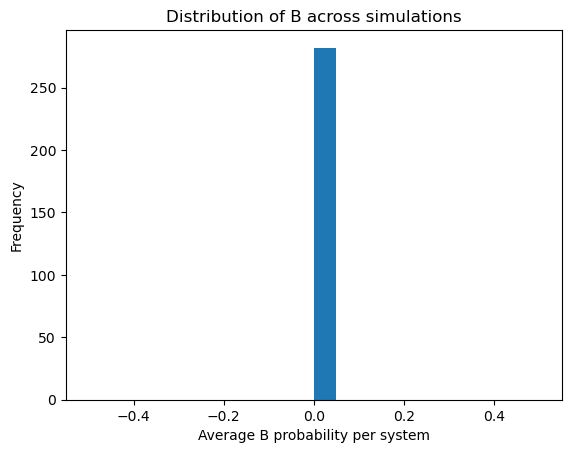

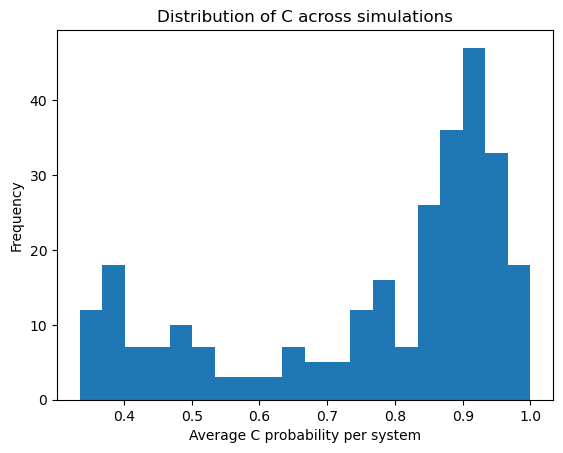

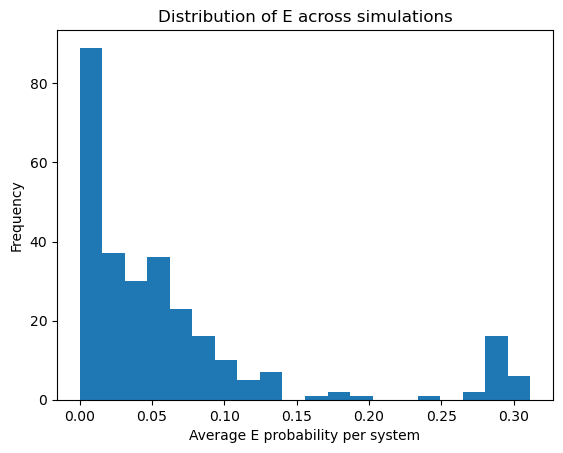

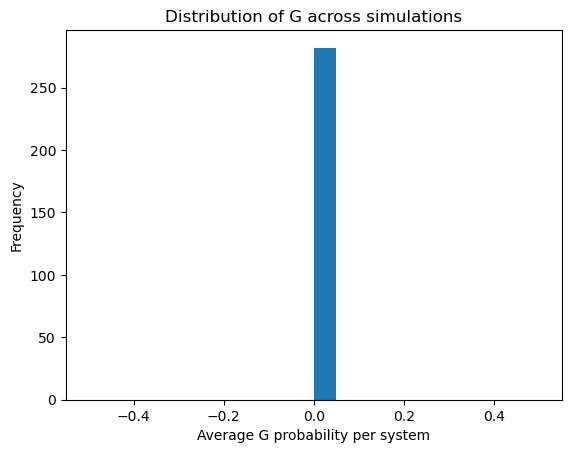

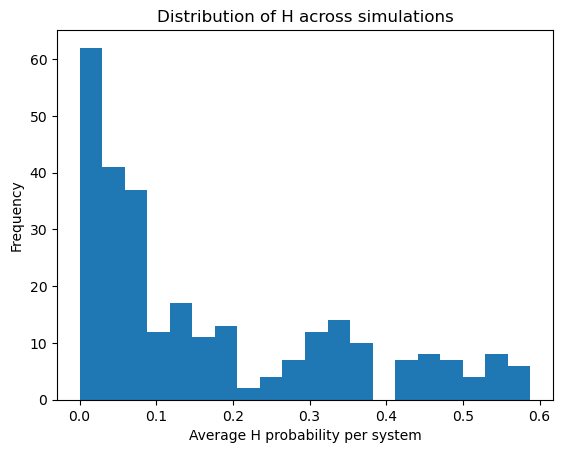

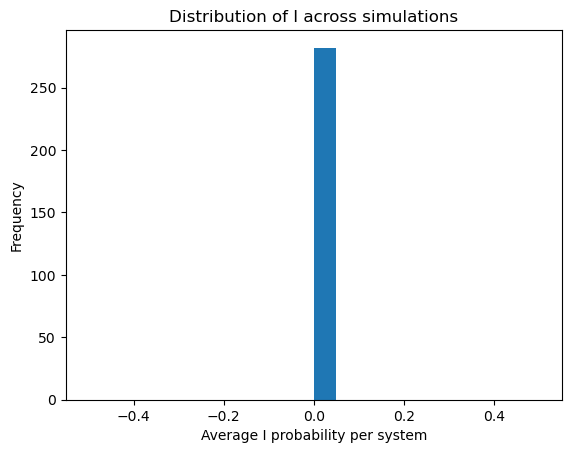

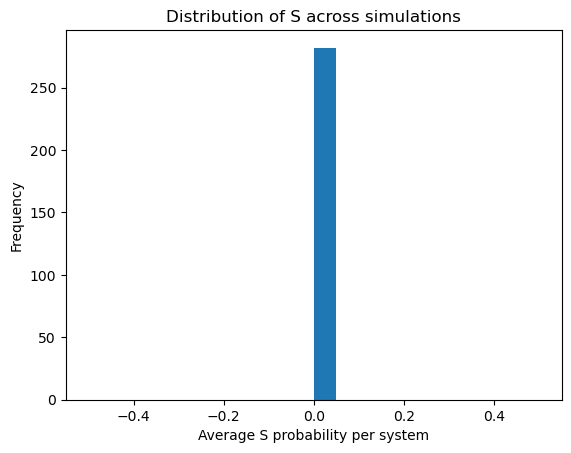

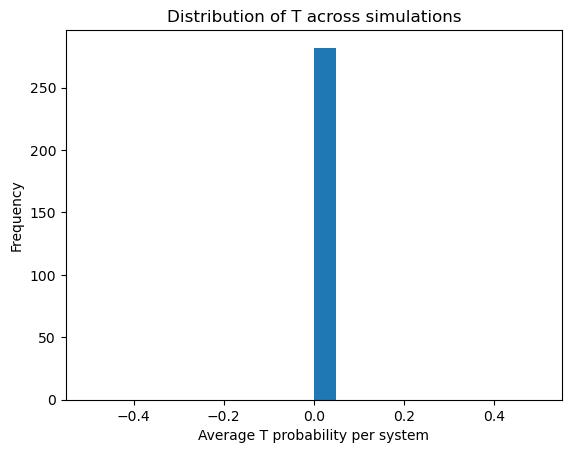

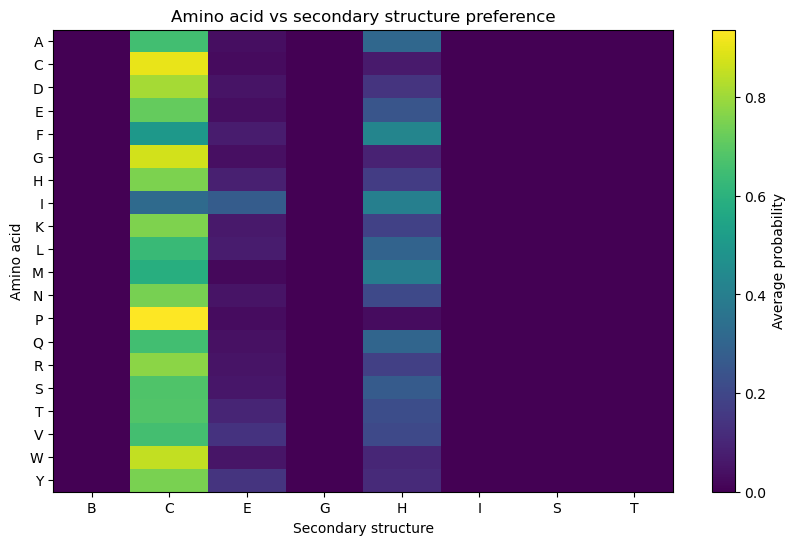

In [33]:
import os
import yaml
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np

# --- Storage ---
avg_coil_per_system = []
ss_per_system = defaultdict(list)  
# ss_per_system["C"] = [avg_C_system1, avg_C_system2, ...]

aa_ss_counts = defaultdict(lambda: defaultdict(list))

# --- Loop over systems ---
for system in systems:
    path = os.path.join(databankPath, "Data", "Simulations", system["path"])
    secondary_structure_file = os.path.join(path, "secondary_structure.yaml")

    try:
        with open(secondary_structure_file, "r") as f:
            data = yaml.safe_load(f)
    except FileNotFoundError:
        print(f"Missing: {secondary_structure_file}")
        continue

    # --- per-system averages for each SS type ---
    ss_sums = defaultdict(list)

    for residue, ss_dict in data.items():
        for ss_type, prob in ss_dict.items():
            ss_sums[ss_type].append(prob)

            # AA-level aggregation
            aa = residue.split("_")[1]
            aa_ss_counts[aa][ss_type].append(prob)

    # compute system-level averages
    for ss_type, vals in ss_sums.items():
        ss_per_system[ss_type].append(np.mean(vals))

# =========================
# 📊 1. Coil distribution (existing)
# =========================
plt.figure()
plt.hist(ss_per_system["C"], bins=20)
plt.xlabel("Average coil probability per system")
plt.ylabel("Frequency")
plt.title("Coil (C) distribution across simulations")
plt.show()

# =========================
# 📊 2. Distribution for EACH SS type
# =========================
ss_types = sorted(ss_per_system.keys())

for ss in ss_types:
    plt.figure()
    plt.hist(ss_per_system[ss], bins=20)
    plt.xlabel(f"Average {ss} probability per system")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {ss} across simulations")
    plt.show()

# =========================
# 📊 3. AA vs SS heatmap (same as before)
# =========================

aa_list = sorted(aa_ss_counts.keys())
ss_types_matrix = sorted(next(iter(aa_ss_counts.values())).keys())

matrix = []

for aa in aa_list:
    row = []
    for ss in ss_types_matrix:
        values = aa_ss_counts[aa][ss]
        row.append(np.mean(values) if values else 0)
    matrix.append(row)

matrix = np.array(matrix)

plt.figure(figsize=(10, 6))
plt.imshow(matrix, aspect='auto')
plt.colorbar(label="Average probability")

plt.xticks(range(len(ss_types_matrix)), ss_types_matrix)
plt.yticks(range(len(aa_list)), aa_list)

plt.xlabel("Secondary structure")
plt.ylabel("Amino acid")
plt.title("Amino acid vs secondary structure preference")

plt.show()

# Search similar proteins

In [34]:
from Bio.Blast import NCBIWWW
from Bio.Blast import NCBIXML

sequence = "MAAVQAAEVKVDGSEPKLSKNELKRRLKAEKKVAEKEAKQKELSEKQLSQATAAATNHTTDNGVGPEEESVD"

# Run BLAST
result_handle = NCBIWWW.qblast("blastp", "pdb", sequence)

# Parse results
blast_record = NCBIXML.read(result_handle)

for alignment in blast_record.alignments[:5]:
    print(alignment.title)
    for hsp in alignment.hsps:
        print("E-value:", hsp.expect)

pdb|6CHD|A Chain A, Lysine--tRNA ligase [Homo sapiens] >pdb|6CHD|B Chain B, Lysine--tRNA ligase [Homo sapiens] >pdb|9DOW|A Chain A, Lysine--tRNA ligase [Homo sapiens] >pdb|9DOW|B Chain B, Lysine--tRNA ligase [Homo sapiens] >pdb|9DPA|A Chain A, Lysine--tRNA ligase [Homo sapiens] >pdb|9DPA|B Chain B, Lysine--tRNA ligase [Homo sapiens] >pdb|9DPB|A Chain A, Lysine--tRNA ligase [Homo sapiens] >pdb|9DPB|B Chain B, Lysine--tRNA ligase [Homo sapiens] >pdb|9DPL|A Chain A, Lysine--tRNA ligase [Homo sapiens] >pdb|9DPL|B Chain B, Lysine--tRNA ligase [Homo sapiens]
E-value: 1.36541e-40


In [36]:
import requests

sequence = "MAAVQAAEVKVDGSEPKLSKNELKRRLKAEKKVAEKEAKQKELSEKQLSQATAAATNHTTDNGVGPEEESVD"

url = "https://rest.uniprot.org/uniprotkb/search"

params = {
    "query": sequence,
    "format": "json",
    "size": 5
}

response = requests.get(url, params=params)
data = response.json()

for result in data["results"]:
    print(result["primaryAccession"], result["organism"]["scientificName"])

In [37]:
import requests
import json

sequence = "MAAVQAAEVKVDGSEPKLSKNELKRRLKAEKKVAEKEAKQKELSEKQLSQATAAATNHTTDNGVGPEEESVD"

query = {
  "query": {
    "type": "terminal",
    "service": "sequence",
    "parameters": {
      "evalue_cutoff": 1,
      "identity_cutoff": 0.3,
      "target": "pdb_protein_sequence",
      "value": sequence
    }
  },
  "return_type": "entry"
}

url = "https://search.rcsb.org/rcsbsearch/v2/query"
response = requests.post(url, json=query)
results = response.json()

for hit in results["result_set"][:5]:
    print(hit["identifier"])

6CHD
9DOW
9DPA
9DPB
9DPL


In [38]:
import requests

sequence = "MAAVQAAEVKVDGSEPKLSKNELKRRLKAEKKVAEKEAKQKELSEKQLSQATAAATNHTTDNGVGPEEESVD"

# Submit job
url = "https://rest.uniprot.org/idmapping/run"
params = {
    "from": "UniProtKB_AC-ID",
    "to": "UniProtKB",
    "ids": sequence
}

response = requests.post(url, data=params)
print(response.text)

{"jobId":"6oh0MgXuRH"}


In [39]:
import requests

job_id = "6oh0MgXuRH"

status_url = f"https://rest.uniprot.org/idmapping/status/{job_id}"
response = requests.get(status_url)

print(response.json())

{'results': [], 'failedIds': ['MAAVQAAEVKVDGSEPKLSKNELKRRLKAEKKVAEKEAKQKELSEKQLSQATAAATNHTTDNGVGPEEESVD'], 'obsoleteCount': 0}


In [41]:
from Bio.Blast import NCBIWWW
from Bio.Blast import NCBIXML

sequence = "MAAVQAAEVKVDGSEPKLSKNELKRRLKAEKKVAEKEAKQKELSEKQLSQATAAATNHTTDNGVGPEEESVD"

result_handle = NCBIWWW.qblast("blastp", "swissprot", sequence)

blast_record = NCBIXML.read(result_handle)

for alignment in blast_record.alignments[:5]:
    print("\n=== HIT ===")
    print("Title:", alignment.title)

    for hsp in alignment.hsps:
        identity = (hsp.identities / hsp.align_length) * 100
        similarity = (hsp.positives / hsp.align_length) * 100

        print(f"Alignment length: {hsp.align_length}")
        print(f"Identity: {identity:.2f}%")
        print(f"Similarity (positives): {similarity:.2f}%")
        print(f"E-value: {hsp.expect}")
        print(f"Bit score: {hsp.bits}")
    


=== HIT ===
Title: sp|Q15046.3| RecName: Full=Lysine--tRNA ligase; AltName: Full=Lysyl-tRNA synthetase; Short=LysRS [Homo sapiens]
Alignment length: 72
Identity: 100.00%
Similarity (positives): 100.00%
E-value: 4.76869e-40
Bit score: 140.969

=== HIT ===
Title: sp|Q99MN1.1| RecName: Full=Lysine--tRNA ligase; AltName: Full=Lysyl-tRNA synthetase; Short=LysRS [Mus musculus]
Alignment length: 72
Identity: 79.17%
Similarity (positives): 88.89%
E-value: 2.17368e-26
Bit score: 102.834

=== HIT ===
Title: sp|P37879.1| RecName: Full=Lysine--tRNA ligase; AltName: Full=Lysyl-tRNA synthetase; Short=LysRS [Cricetulus griseus]
Alignment length: 73
Identity: 80.82%
Similarity (positives): 87.67%
E-value: 1.01864e-22
Bit score: 92.4337

=== HIT ===
Title: sp|Q5XIM7.1| RecName: Full=Lysine--tRNA ligase; AltName: Full=Lysyl-tRNA synthetase; Short=LysRS [Rattus norvegicus]
Alignment length: 54
Identity: 79.63%
Similarity (positives): 90.74%
E-value: 1.72028e-12
Bit score: 63.5438


In [42]:
sequence = "MAAVQAAEVKVDGSEPKLSKNELKRRLKAEKKVAEKEAKQKELSEKQLSQATAAATNHTTDNGVGPEEESVD"

result_handle = NCBIWWW.qblast("blastp", "pdb", sequence)

blast_record = NCBIXML.read(result_handle)

for alignment in blast_record.alignments[:5]:
    print("\n=== HIT ===")
    print("Title:", alignment.title)

    for hsp in alignment.hsps:
        identity = (hsp.identities / hsp.align_length) * 100
        similarity = (hsp.positives / hsp.align_length) * 100

        print(f"Alignment length: {hsp.align_length}")
        print(f"Identity: {identity:.2f}%")
        print(f"Similarity (positives): {similarity:.2f}%")
        print(f"E-value: {hsp.expect}")
        print(f"Bit score: {hsp.bits}")
    


=== HIT ===
Title: pdb|6CHD|A Chain A, Lysine--tRNA ligase [Homo sapiens] >pdb|6CHD|B Chain B, Lysine--tRNA ligase [Homo sapiens] >pdb|9DOW|A Chain A, Lysine--tRNA ligase [Homo sapiens] >pdb|9DOW|B Chain B, Lysine--tRNA ligase [Homo sapiens] >pdb|9DPA|A Chain A, Lysine--tRNA ligase [Homo sapiens] >pdb|9DPA|B Chain B, Lysine--tRNA ligase [Homo sapiens] >pdb|9DPB|A Chain A, Lysine--tRNA ligase [Homo sapiens] >pdb|9DPB|B Chain B, Lysine--tRNA ligase [Homo sapiens] >pdb|9DPL|A Chain A, Lysine--tRNA ligase [Homo sapiens] >pdb|9DPL|B Chain B, Lysine--tRNA ligase [Homo sapiens]
Alignment length: 72
Identity: 100.00%
Similarity (positives): 100.00%
E-value: 1.36541e-40
Bit score: 140.969


In [43]:
from Bio.Blast import NCBIWWW
from Bio.Blast import NCBIXML

def blast_sequence(sequence, top_n=5):
    """
    Run BLAST against UniProt (SwissProt) and PDB.
    
    Returns:
        dict with keys:
            - 'uniprot': list of hits
            - 'pdb': list of hits
    """

    def parse_hits(blast_record, seq_len):
        hits = []

        for alignment in blast_record.alignments[:top_n]:
            for hsp in alignment.hsps:
                identity = (hsp.identities / hsp.align_length) * 100
                similarity = (hsp.positives / hsp.align_length) * 100
                coverage = (hsp.align_length / seq_len) * 100

                hit = {
                    "title": alignment.title,
                    "length": alignment.length,
                    "identity_%": round(identity, 2),
                    "similarity_%": round(similarity, 2),
                    "coverage_%": round(coverage, 2),
                    "e_value": hsp.expect,
                    "bit_score": hsp.bits
                }

                hits.append(hit)

        return hits

    seq_len = len(sequence)

    # --- UniProt (SwissProt) ---
    sp_handle = NCBIWWW.qblast("blastp", "swissprot", sequence)
    sp_record = NCBIXML.read(sp_handle)
    sp_hits = parse_hits(sp_record, seq_len)

    # --- PDB ---
    pdb_handle = NCBIWWW.qblast("blastp", "pdb", sequence)
    pdb_record = NCBIXML.read(pdb_handle)
    pdb_hits = parse_hits(pdb_record, seq_len)

    return {
        "uniprot": sp_hits,
        "pdb": pdb_hits
    }

In [44]:
sequence = "MAAVQAAEVKVDGSEPKLSKNELKRRLKAEKKVAEKEAKQKELSEKQLSQATAAATNHTTDNGVGPEEESVD"

for system

results = blast_sequence(sequence)

print("\n--- UniProt hits ---")
for hit in results["uniprot"]:
    print(hit)

print("\n--- PDB hits ---")
for hit in results["pdb"]:
    print(hit)


--- UniProt hits ---
{'title': 'sp|Q15046.3| RecName: Full=Lysine--tRNA ligase; AltName: Full=Lysyl-tRNA synthetase; Short=LysRS [Homo sapiens]', 'length': 597, 'identity_%': 100.0, 'similarity_%': 100.0, 'coverage_%': 100.0, 'e_value': 4.76869e-40, 'bit_score': 140.969}
{'title': 'sp|Q99MN1.1| RecName: Full=Lysine--tRNA ligase; AltName: Full=Lysyl-tRNA synthetase; Short=LysRS [Mus musculus]', 'length': 595, 'identity_%': 79.17, 'similarity_%': 88.89, 'coverage_%': 100.0, 'e_value': 2.17368e-26, 'bit_score': 102.834}
{'title': 'sp|P37879.1| RecName: Full=Lysine--tRNA ligase; AltName: Full=Lysyl-tRNA synthetase; Short=LysRS [Cricetulus griseus]', 'length': 597, 'identity_%': 80.82, 'similarity_%': 87.67, 'coverage_%': 101.39, 'e_value': 1.01864e-22, 'bit_score': 92.4337}
{'title': 'sp|Q5XIM7.1| RecName: Full=Lysine--tRNA ligase; AltName: Full=Lysyl-tRNA synthetase; Short=LysRS [Rattus norvegicus]', 'length': 626, 'identity_%': 79.63, 'similarity_%': 90.74, 'coverage_%': 75.0, 'e_value'

In [51]:
results

#for i in results['uniprot']:
#    print(i)

{'uniprot': [{'title': 'sp|Q15046.3| RecName: Full=Lysine--tRNA ligase; AltName: Full=Lysyl-tRNA synthetase; Short=LysRS [Homo sapiens]',
   'length': 597,
   'identity_%': 100.0,
   'similarity_%': 100.0,
   'coverage_%': 100.0,
   'e_value': 4.76869e-40,
   'bit_score': 140.969},
  {'title': 'sp|Q99MN1.1| RecName: Full=Lysine--tRNA ligase; AltName: Full=Lysyl-tRNA synthetase; Short=LysRS [Mus musculus]',
   'length': 595,
   'identity_%': 79.17,
   'similarity_%': 88.89,
   'coverage_%': 100.0,
   'e_value': 2.17368e-26,
   'bit_score': 102.834},
  {'title': 'sp|P37879.1| RecName: Full=Lysine--tRNA ligase; AltName: Full=Lysyl-tRNA synthetase; Short=LysRS [Cricetulus griseus]',
   'length': 597,
   'identity_%': 80.82,
   'similarity_%': 87.67,
   'coverage_%': 101.39,
   'e_value': 1.01864e-22,
   'bit_score': 92.4337},
  {'title': 'sp|Q5XIM7.1| RecName: Full=Lysine--tRNA ligase; AltName: Full=Lysyl-tRNA synthetase; Short=LysRS [Rattus norvegicus]',
   'length': 626,
   'identity_%':

In [85]:
for system in systems:
    path = os.path.join(databankPath, "Data", "Simulations", system["path"])
    cross_linking_file = os.path.join(path, "cross_link_data.yaml")
    #for i in system:
    #    print(i)
    try:
        with open(cross_linking_file, "r") as f:
            data = yaml.safe_load(f)
        print(system['SYSTEM'], system['ID'])
        print('Uniprot:')
        try:
            print(data['uniprot'][0]['title'],data['uniprot'][0]['similarity_%'])
        except:
            print('Uniprot not found')    
        print('PDB:')
        try:
            print(data['pdb'][0]['title'],data['pdb'][0]['similarity_%'])
        except:
            print('PDB not found')    
        print()
        #print(data['uniprot'])
    except FileNotFoundError:
        print(f"Missing: {cross_linking_file}")
        continue



Charged sequence with tris 285
Uniprot:
sp|Q99109.1| RecName: Full=Repellent protein 1; Contains: RecName: Full=Rep1-1; Contains: RecName: Full=Rep1-2; Contains: RecName: Full=Rep1-3; Contains: RecName: Full=Rep1-4; Contains: RecName: Full=Rep1-5; Contains: RecName: Full=Rep1-6; Contains: RecName: Full=Rep1-7; Contains: RecName: Full=Rep1-8; Contains: RecName: Full=Rep1-9; Contains: RecName: Full=Rep1-10; Contains: RecName: Full=Rep1-11; Flags: Precursor [Mycosarcoma maydis] 68.18
PDB:
pdb|6FIG|A Chain A, Receptor-like protein kinase ANXUR1 [Arabidopsis thaliana] >pdb|6FIG|B Chain B, Receptor-like protein kinase ANXUR1 [Arabidopsis thaliana] 70.59

KRS1-72_salt 138
Uniprot:
sp|Q15046.3| RecName: Full=Lysine--tRNA ligase; AltName: Full=Lysyl-tRNA synthetase; Short=LysRS [Homo sapiens] 100.0
PDB:
pdb|6CHD|A Chain A, Lysine--tRNA ligase [Homo sapiens] >pdb|6CHD|B Chain B, Lysine--tRNA ligase [Homo sapiens] >pdb|9DOW|A Chain A, Lysine--tRNA ligase [Homo sapiens] >pdb|9DOW|B Chain B, Lysine

# Plot systems with experimental data available

In [93]:
# Loop over simulations in the Databank
system_IDs_with_cs_data = []
system_IDs_with_sr_data = []

for system in systems:
    if len(system['EXPERIMENT']['chemical_shift']['alignment_score']) > 0 :
        system_IDs_with_cs_data.append(system['ID'])
    if len(system['EXPERIMENT']['spin_relaxation']['alignment_score']) > 0:
        system_IDs_with_sr_data.append(system['ID'])
    #print()

In [126]:
total_number = 0
cs_evaluated = 0
sr_evaluated = 0
both_evaluated = 0

systems_titles_no_sr = [] 
systems_titles_no_cs = [] 

systems_titles_with_sr = [] 
systems_titles_with_cs = [] 


for system in systems:
    sr_value = False
    cs_value = False

    total_number += 1
    
    if system['ID'] in system_IDs_with_sr_data:
        sr_evaluated += 1
        sr_value = True
        if system['SYSTEM'] not in systems_titles_with_sr:
            systems_titles_with_sr.append(system['SYSTEM'])
        
    if system['ID'] not in system_IDs_with_sr_data:
        if system['SYSTEM'] not in systems_titles_no_sr:
            systems_titles_no_sr.append(system['SYSTEM'])
        
    
    if system['ID'] in system_IDs_with_cs_data:
        cs_evaluated += 1
        cs_value = True
        if system['SYSTEM'] not in systems_titles_with_cs:
            systems_titles_with_cs.append(system['SYSTEM'])
    
    if system['ID'] not in system_IDs_with_cs_data:
        if system['SYSTEM'] not in systems_titles_no_cs:
            systems_titles_no_cs.append(system['SYSTEM'])

    if cs_value and sr_value:
        both_evaluated += 1

print('Chemical shifts evaluated: ', round(100*cs_evaluated/total_number), '%,', ' Number of systems: ', cs_evaluated)
print('Spin relaxations evaluated: ', round(100*sr_evaluated/total_number), '%', ' Number of systems: ', sr_evaluated)
print('Both evaluated: ', round(100*both_evaluated/total_number), '%', ' Number of systems: ', both_evaluated)
            
        #print(system['SYSTEM'])

#print(system_IDs_with_cs_data)
#print(system_IDs_with_sr_data)

Chemical shifts evaluated:  32 %,  Number of systems:  101
Spin relaxations evaluated:  64 %  Number of systems:  201
Both evaluated:  32 %  Number of systems:  101


In [113]:
print(systems_titles_no_sr)
print()
print(systems_titles_no_cs)

['Charged sequence with tris', 'wrapping silk (AcSp1)', 'Protein linker', 'Charged sequence with NaCl', 'silk protein', 'TonBCTD', 'CDNF', 'Charged protonated sequence with CaCl', 'Charged sequence with NaCl and phosphate', 'Charged sequence with CaCl', 'Charged protonated sequence with NaCl', 'Charged sequence with CaCl and phosphate', 'TonB', 'Charged sequence protonated peptide', 'TonB low pH with CaCl', 'Charged sequence peptide', 'EN2', 'TonB low pH with NaCl', 'TonB with CaCl, deprotonated']

['Charged sequence with tris', 'KRS1-72_salt', 'KRS1-72', 'wrapping silk (AcSp1)', 'Protein linker', 'ChiZ_salt', 'ChiZ1-64', 'Charged sequence with NaCl', 'silk protein', 'TonBCTD', 'CDNF', 'Charged protonated sequence with CaCl', 'Charged sequence with NaCl and phosphate', 'Charged sequence with CaCl', 'Charged protonated sequence with NaCl', 'Charged sequence with CaCl and phosphate', 'TonB', 'Charged sequence protonated peptide', 'TonB low pH with CaCl', 'Charged sequence peptide', 'EN2'

In [127]:
print(systems_titles_with_sr)
print()
print(systems_titles_with_cs)

['KRS1-72_salt', 'asyn_salt', 'KRS1-72', 'asyn', 'ChiZ_salt', 'ChiZ1-64', 'calmodulin', 'icl2', 'Calmodulin']

['asyn_salt', 'asyn', 'calmodulin', 'icl2', 'Calmodulin']


# Plotting pie diagram of temperatures

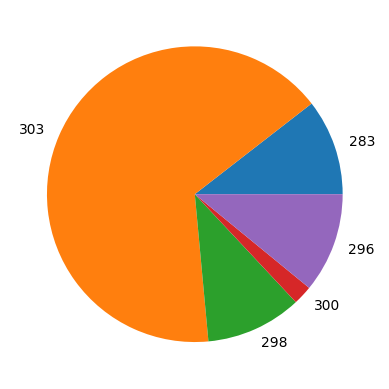

In [11]:
#db_data.pie_temperature()
import collections
temps = [ int(float(system['TEMPERATURE'])) for system in systems]
counter = collections.Counter(temps)
plt.pie(counter.values(),labels=counter.keys());

<Figure size 640x480 with 0 Axes>

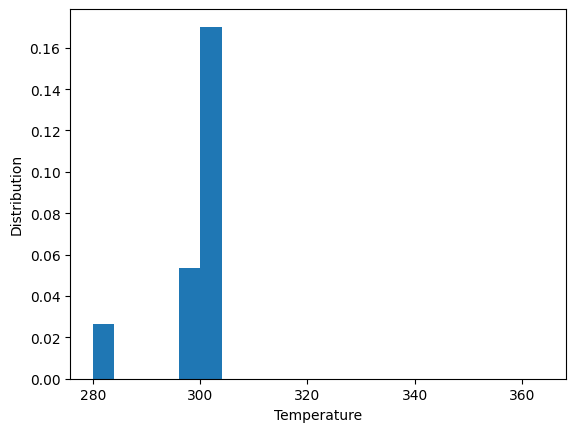

<Figure size 640x480 with 0 Axes>

In [12]:
distTemps = plt.hist(temps, density=True, bins=np.arange(280,365,4))
plt.xlabel('Temperature')
plt.ylabel('Distribution')
plt.figure()

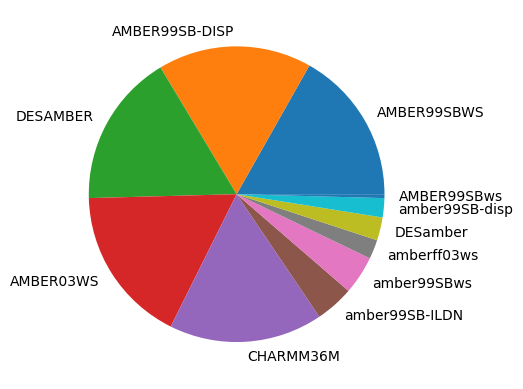

In [13]:

temps = [ s['FF'] for s in systems if 'FF' in s]
counter = collections.Counter(temps)
plt.pie(counter.values(),labels=counter.keys());

Force field information missing froma7f/9f3/a7f9f36feaa77791483dadb0157f86a6a519f2c3/a30f01e8771c44dc59b78753d1dd27ca67920e38/
Force field information missing fromc04/cdb/c04cdb61143bb72ba2ddee11599e6bbfaf6cb211/a31f42800216d84d2242eae2af8ac2cbd6b033ee/
{'Orange': 5, 'Poger': 4, 'GAFFlipid': 3, 'OpenFF': 4, 'Ulmschneider': 2, 'GROMOS 43A1-S3': 2, 'OPLS3e': 4, 'Chiu Gromos': 1, 'ECC-CHARMM36': 3}


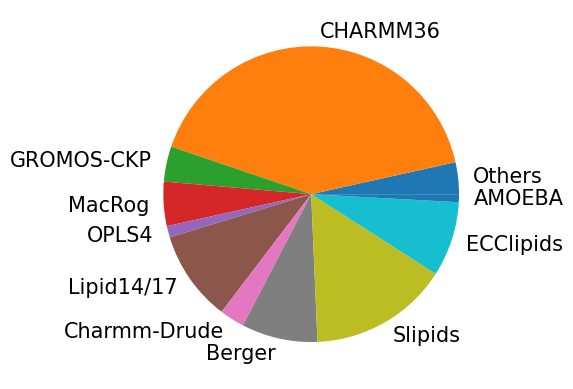

In [12]:
ffs = []

for system in systems:
    try:
        ff = system['FF']
    except:
        print('Force field information missing from' + system['path'])
    
    if 'GROMOS-CKP' in ff or 'gromos-ckp' in ff:
        ffs.append('GROMOS-CKP')
    elif 'Charmm-Drude' in ff:
        ffs.append('Charmm-Drude')
    elif 'Berger' in ff:
        ffs.append('Berger')    
    elif 'Slipids' in ff or 'slipids' in ff:
        ffs.append('Slipids')    
    elif 'lipid17ecc' in ff or 'ECC-lipids' in ff:
        ffs.append('ECClipids')
    elif 'ECC-CHARMM36' in ff:
        ffs.append(ff)
    elif 'CHARMM36' in ff or 'Charmm36' in ff:
        ffs.append('CHARMM36')
    elif 'Lipid14' in ff or 'Lipid17' in ff or 'lipid17' in ff:
        ffs.append('Lipid14/17')
    elif 'Poger' in ff:
        ffs.append('Poger')
    else:
        ffs.append(ff)
    
counter = collections.Counter(ffs)
several = {}
several['Others'] = 0
less = {}
for i in counter:
    if counter[i] > 5:
        several[i] = counter[i]
    else:
        several['Others'] += counter[i] 
        less[i] = counter[i]
#plt.pie(counter.values(),labels=counter.keys(), textprops={'fontsize': 15});
plt.pie(several.values(),labels=several.keys(), textprops={'fontsize': 15});
#plt.savefig('../../../DataBankManuscriptText/Figures/FFpie.pdf', bbox_inches='tight')
print(less)

{'DPPE': 3, 'TMCL': 1, 'BOG': 4, 'CER': 5, 'DOG': 4, 'DYPC': 3, 'SAPI25': 6, 'DLIPC': 6, 'SDPE': 4, 'PYPC': 3, 'DSPC': 2, 'DRPC': 3, 'TLCL_0H': 4, 'DCHOL': 2, 'SLiPC': 3, 'SM18': 2, 'DPPG': 2, 'POPI': 2, 'CER180': 1, 'DDOPC': 2, 'DEPC': 1, 'SDG': 4, 'C30': 1, 'DPPGK': 1, 'GB3': 1, 'GM1': 3, 'SAPI': 1, 'SLPI': 1, 'PAzePCdeprot': 1, 'PAzePCprot': 1, 'SAPI24': 1}


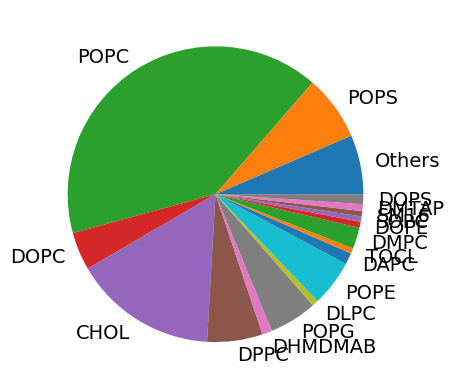

In [13]:
lipids = []
for system in systems:
    for lipid in system['COMPOSITION']:
        if lipid in lipids_set:
            lipids.append(lipid)
counter = collections.Counter(lipids)
several = {}
several['Others'] = 0
less = {}
for i in counter:
    if counter[i] > 6:
        several[i] = counter[i]
    else:
        several['Others'] += counter[i] 
        less[i] = counter[i]

#plt.figure(figsize=(11,5))
plt.pie(several.values(),labels=several.keys(), textprops={'fontsize': 14});
#plt.savefig('../../../DataBankManuscriptText/Figures/FFlipids.pdf', bbox_inches='tight')
print(less)